## 🧩 Bases de Datos y SQL desde Python

Trabajar con bases de datos es una habilidad esencial para cualquier analista de datos.  
Nos permite acceder a información estructurada, automatizar consultas y conectar los resultados con nuestros análisis en Python.

---

### 🧠 Conocimientos Clave

| Área | Qué debes saber | Por qué importa |
|------|------------------|-----------------|
| **Fundamentos de SQL** | SELECT, WHERE, GROUP BY, JOIN, funciones de agregación | Base para consultar y transformar datos almacenados |
| **Modelo relacional** | Tablas, llaves primarias y foráneas, relaciones uno a muchos | Permite comprender cómo se conectan los datos |
| **Pandas + SQL** | `read_sql_query()`, `to_sql()` | Para combinar SQL con análisis y visualización |
| **SQLAlchemy (ORM)** | Concepto de motores, dialectos y abstracción de SQL | Profesionaliza la conexión a distintas bases de datos |

---

### 🧱 Habilidades a Desarrollar

- Leer y comprender esquemas relacionales (diagramas entidad-relación)  
- Conectarse a diferentes tipos de bases de datos (SQLite, MySQL, PostgreSQL)  
- Combinar SQL con Python para generar reportes o ETL automatizados  
- Cargar resultados en Pandas y visualizarlos directamente  
- Escribir scripts reproducibles que lean, limpien y guarden datos desde SQL  

---

### 📘 Libros Recomendados

1. **_Learning SQL (3rd Ed.)_ — Alan Beaulieu (O’Reilly)**  
   Excelente base teórica y práctica, desde consultas simples hasta subconsultas y joins complejos.

2. **_SQL for Data Analysis_ — Cathy Tanimura (O’Reilly)**  
   Orientado a analistas. Muestra cómo usar SQL para responder preguntas de negocio.

3. **_Essential SQLAlchemy (2nd Ed.)_ — Jason Myers & Rick Copeland**  
   Ideal para quienes quieran avanzar al nivel profesional de automatización con bases de datos desde Python.

---

### 💡 Consejos Finales

- Empieza con **SQLite** (no requiere instalación ni servidor).  
- Usa **Pandas** para manipular los resultados SQL directamente.  
- SQL es un lenguaje declarativo: enfócate en *qué* quieres obtener, no *cómo*.  
- Integra SQL en tus proyectos de análisis: la mayoría de los datos corporativos viven en bases de datos.

---


### Database Description

- The Sakila sample database is a fictitious database designed to represent a DVD rental store. The tables of the database include film, film_category, actor, customer, rental, payment and inventory among others.
- The Sakila sample database is intended to provide a standard schema that can be used for examples in books, tutorials, articles, samples, and so forth.
- Detailed information about the database can be found on the MySQL website: https://dev.mysql.com/doc/sakila/en/

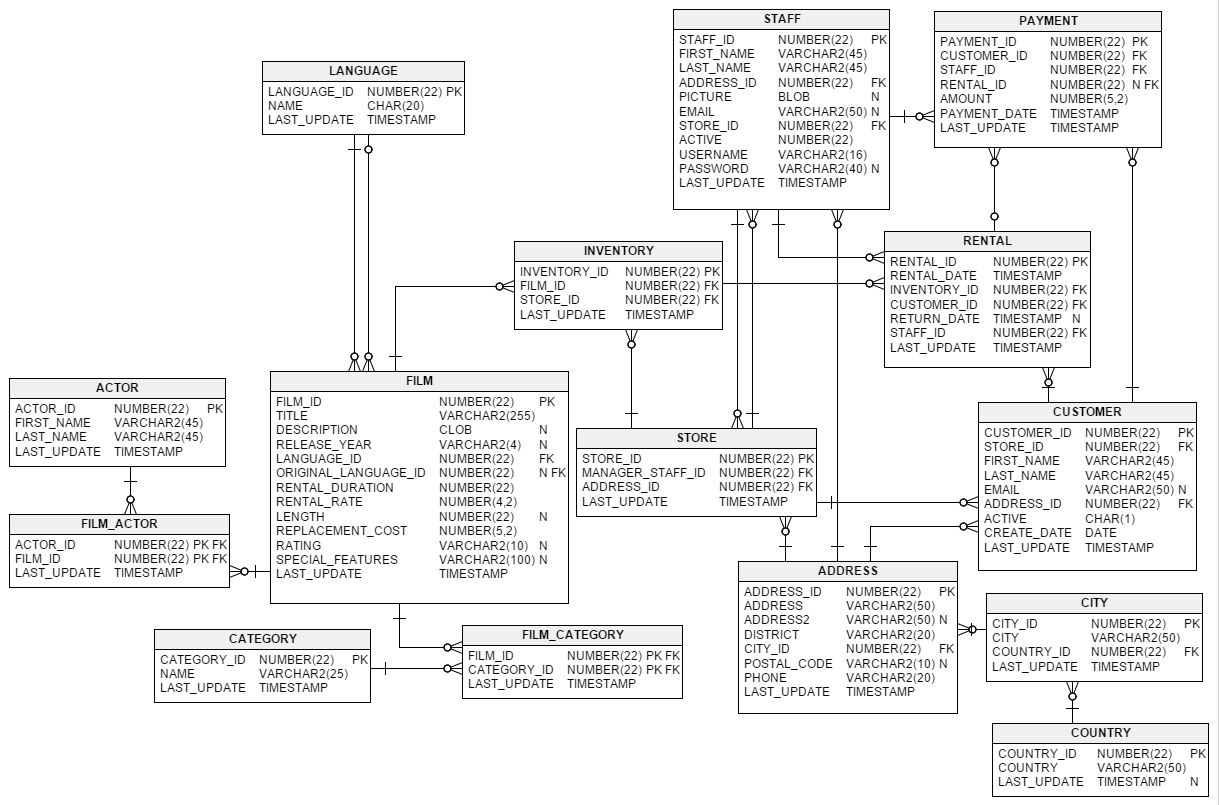

In [8]:
import sqlite3

sakila = "../../data/sqlite-sakila.db"

# 1) Conexión
conn = sqlite3.connect(sakila)
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tablas = cursor.fetchall()

for t in tablas:
    print(t[0])

conn.close()


actor
country
city
address
language
category
customer
film
film_actor
film_category
film_text
inventory
staff
store
payment
rental


In [9]:
# 1) Conexión
conn = sqlite3.connect(sakila)
cur = conn.cursor()

# 2) Query: TOP 10 películas por número de rentas
sql = """
SELECT 
    f.film_id,
    f.title,
    COUNT(r.rental_id) AS rentals
FROM film AS f
JOIN inventory AS i  ON i.film_id = f.film_id
JOIN rental   AS r  ON r.inventory_id = i.inventory_id
GROUP BY f.film_id, f.title
ORDER BY rentals DESC, f.title ASC
LIMIT 10;
"""

cur.execute(sql)
rows = cur.fetchall()

# 3) Mostrar resultado simple
for film_id, title, rentals in rows:
    print(f"{film_id:4d} | {title[:40]:40s} | {rentals:3d}")

conn.close()


 103 | BUCKET BROTHERHOOD                       |  34
 738 | ROCKETEER MOTHER                         |  33
 331 | FORWARD TEMPLE                           |  32
 382 | GRIT CLOCKWORK                           |  32
 489 | JUGGLER HARDLY                           |  32
 730 | RIDGEMONT SUBMARINE                      |  32
 767 | SCALAWAG DUCK                            |  32
  31 | APACHE DIVINE                            |  31
 369 | GOODFELLAS SALUTE                        |  31
 418 | HOBBIT ALIEN                             |  31


In [ ]:
import pandas as pd

conn = sqlite3.connect(sakila)

df = pd.read_sql_query(sql, conn)

conn.close()

df

,film_id,title,rentals
0,103,BUCKET BROTHERHOOD,34
1,738,ROCKETEER MOTHER,33
2,331,FORWARD TEMPLE,32
3,382,GRIT CLOCKWORK,32
4,489,JUGGLER HARDLY,32
5,730,RIDGEMONT SUBMARINE,32
6,767,SCALAWAG DUCK,32
7,31,APACHE DIVINE,31
8,369,GOODFELLAS SALUTE,31
9,418,HOBBIT ALIEN,31


In [15]:
# pip install sqlalchemy

import sqlalchemy as sa
import pandas as pd

engine = sa.create_engine("sqlite:///../../data/sqlite-sakila.db")
with engine.connect() as con:

    df = pd.read_sql(
        sa.text("SELECT * FROM film LIMIT 5;"),
        con
    )
    
df.head()

,film_id,title,description,release_year,language_id,original_language_id,rental_duration,rental_rate,length,replacement_cost,rating,special_features,last_update
0,1,ACADEMY DINOSAUR,A Epic Drama of a Feminist And a Mad Scientist...,2006,1,None,6,0.99,86,20.99,PG,"Deleted Scenes,Behind the Scenes",2021-03-06 15:52:00
1,2,ACE GOLDFINGER,A Astounding Epistle of a Database Administrat...,2006,1,None,3,4.99,48,12.99,G,"Trailers,Deleted Scenes",2021-03-06 15:52:00
2,3,ADAPTATION HOLES,A Astounding Reflection of a Lumberjack And a ...,2006,1,None,7,2.99,50,18.99,NC-17,"Trailers,Deleted Scenes",2021-03-06 15:52:00
3,4,AFFAIR PREJUDICE,A Fanciful Documentary of a Frisbee And a Lumb...,2006,1,None,5,2.99,117,26.99,G,"Commentaries,Behind the Scenes",2021-03-06 15:52:00
4,5,AFRICAN EGG,A Fast-Paced Documentary of a Pastry Chef And ...,2006,1,None,6,2.99,130,22.99,G,Deleted Scenes,2021-03-06 15:52:00
